In [1]:
import pandas as pd
import sqlite3

df = pd.read_csv('train.csv')
print(df.shape)
print(df.columns.tolist())

(9800, 18)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


In [2]:
# Convert date columns to actual datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

# Quick check
print(df[['Order Date', 'Ship Date']].head())
print(df['Order Date'].dtype)

  Order Date  Ship Date
0 2017-11-08 2017-11-11
1 2017-11-08 2017-11-11
2 2017-06-12 2017-06-16
3 2016-10-11 2016-10-18
4 2016-10-11 2016-10-18
datetime64[ns]


In [3]:
# Create a SQLite database and load our data into it
conn = sqlite3.connect('superstore.db')
df.to_sql('orders', conn, if_exists='replace', index=False)

print("Data loaded into SQLite successfully")

# Quick test: count rows in the database to confirm it worked
test = pd.read_sql("SELECT COUNT(*) as total_rows FROM orders", conn)
print(test)

Data loaded into SQLite successfully
   total_rows
0        9800


In [4]:
query = """
WITH monthly_sales AS (
  SELECT
    strftime('%Y-%m', "Order Date") AS month,
    SUM(Sales) AS total_sales
  FROM orders
  GROUP BY month
)
SELECT
  month,
  ROUND(total_sales, 2) AS total_sales,
  ROUND(LAG(total_sales) OVER (ORDER BY month), 2) AS prev_month_sales,
  ROUND(((total_sales - LAG(total_sales) OVER (ORDER BY month)) * 100.0 /
    LAG(total_sales) OVER (ORDER BY month)), 2) AS mom_growth_pct
FROM monthly_sales
ORDER BY month;
"""
result = pd.read_sql(query, conn)
print(result)

      month  total_sales  prev_month_sales  mom_growth_pct
0   2015-01     14205.71               NaN             NaN
1   2015-02      4519.89          14205.71          -68.18
2   2015-03     55205.80           4519.89         1121.40
3   2015-04     27906.86          55205.80          -49.45
4   2015-05     23644.30          27906.86          -15.27
5   2015-06     34322.94          23644.30           45.16
6   2015-07     33781.54          34322.94           -1.58
7   2015-08     27117.54          33781.54          -19.73
8   2015-09     81623.53          27117.54          201.00
9   2015-10     31453.39          81623.53          -61.47
10  2015-11     77907.66          31453.39          147.69
11  2015-12     68167.06          77907.66          -12.50
12  2016-01     18066.96          68167.06          -73.50
13  2016-02     11951.41          18066.96          -33.85
14  2016-03     32339.32          11951.41          170.59
15  2016-04     34154.47          32339.32            5.

In [5]:
query2 = """
WITH customer_value AS (
  SELECT "Customer ID", "Customer Name",
    SUM(Sales) AS total_spent,
    COUNT(DISTINCT "Order ID") AS num_orders
  FROM orders
  GROUP BY "Customer ID"
)
SELECT
  CASE
    WHEN total_spent > 5000 THEN 'High Value'
    WHEN total_spent > 2000 THEN 'Mid Value'
    ELSE 'Low Value'
  END AS customer_tier,
  COUNT(*) AS num_customers,
  ROUND(SUM(total_spent), 2) AS tier_total_sales,
  ROUND(AVG(total_spent), 2) AS avg_spent
FROM customer_value
GROUP BY customer_tier
ORDER BY avg_spent DESC;
"""
result2 = pd.read_sql(query2, conn)
print(result2)

  customer_tier  num_customers  tier_total_sales  avg_spent
0    High Value            114         889525.86    7802.86
1     Mid Value            320        1007968.76    3149.90
2     Low Value            359         364042.16    1014.05


In [6]:
query3 = """
WITH region_category_sales AS (
  SELECT Region, "Sub-Category",
    ROUND(SUM(Sales), 2) AS total_sales,
    RANK() OVER (PARTITION BY Region ORDER BY SUM(Sales) DESC) AS rnk
  FROM orders
  GROUP BY Region, "Sub-Category"
)
SELECT * FROM region_category_sales WHERE rnk = 1;
"""
result3 = pd.read_sql(query3, conn)
print(result3)

    Region Sub-Category  total_sales  rnk
0  Central       Chairs     82372.78    1
1     East       Phones     99884.66    1
2    South       Phones     58098.34    1
3     West       Chairs    100023.20    1


In [7]:
query4 = """
SELECT
  "Ship Mode",
  COUNT(*) AS num_orders,
  ROUND(AVG(julianday("Ship Date") - julianday("Order Date")), 2) AS avg_shipping_days,
  ROUND(SUM(Sales), 2) AS total_sales
FROM orders
GROUP BY "Ship Mode"
ORDER BY avg_shipping_days;
"""
result4 = pd.read_sql(query4, conn)
print(result4)

        Ship Mode  num_orders  avg_shipping_days  total_sales
0        Same Day         538               0.04    125219.04
1     First Class        1501               2.18    345572.26
2    Second Class        1902               3.25    449914.18
3  Standard Class        5859               5.01   1340831.31


In [8]:
query5 = """
SELECT
  Segment, Category,
  ROUND(SUM(Sales), 2) AS total_sales,
  ROUND(SUM(Sales) * 100.0 / (SELECT SUM(Sales) FROM orders), 2) AS pct_of_total_sales
FROM orders
GROUP BY Segment, Category
ORDER BY total_sales DESC;
"""
result5 = pd.read_sql(query5, conn)
print(result5)

       Segment         Category  total_sales  pct_of_total_sales
0     Consumer       Technology    401011.66               17.73
1     Consumer        Furniture    387696.26               17.14
2     Consumer  Office Supplies    359352.61               15.89
3    Corporate       Technology    244041.84               10.79
4    Corporate  Office Supplies    224130.54                9.91
5    Corporate        Furniture    220321.70                9.74
6  Home Office       Technology    182402.37                8.07
7  Home Office  Office Supplies    121939.19                5.39
8  Home Office        Furniture    120640.62                5.33


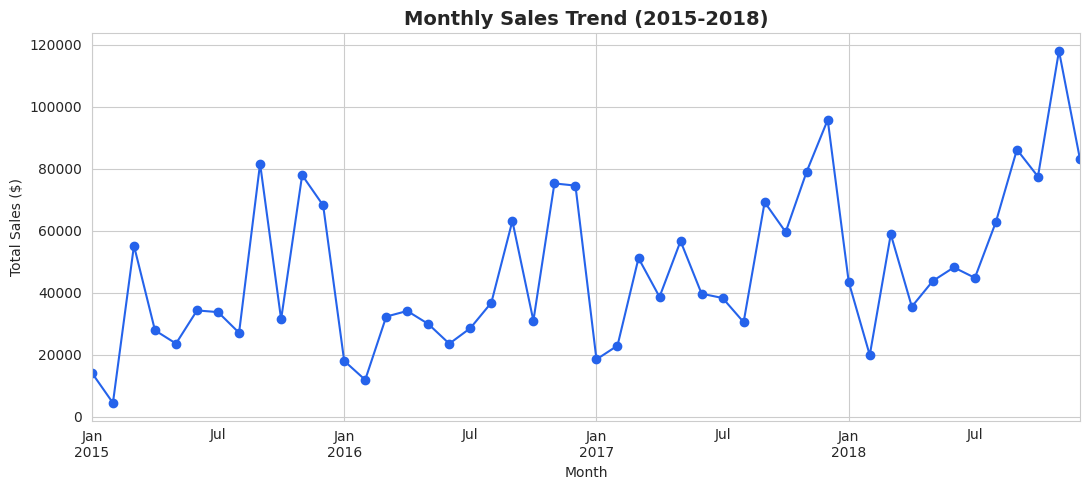

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

monthly = df.set_index('Order Date').resample('ME')['Sales'].sum()

plt.figure(figsize=(11, 5))
monthly.plot(marker='o', color='#2563eb')
plt.title('Monthly Sales Trend (2015-2018)', fontsize=14, fontweight='bold')
plt.ylabel('Total Sales ($)')
plt.xlabel('Month')
plt.tight_layout()
plt.savefig('monthly_sales_trend.png', dpi=120)
plt.show()

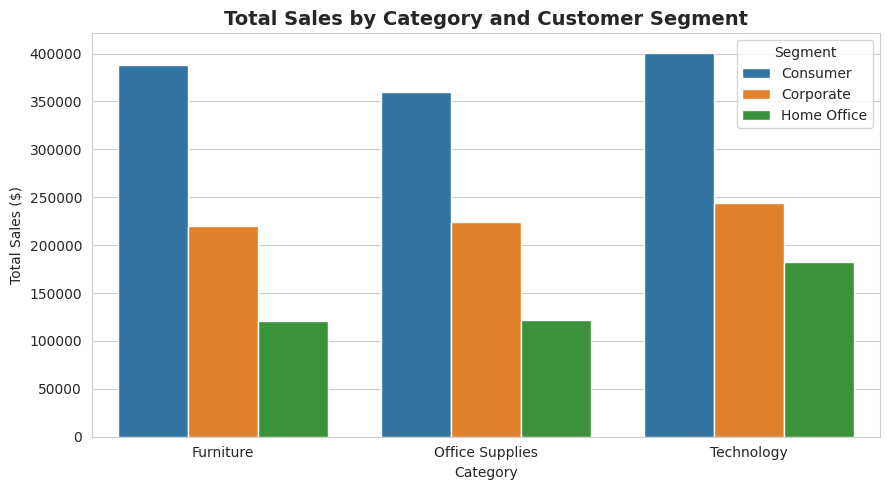

In [10]:
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x='Category', y='Sales', hue='Segment', estimator=sum, errorbar=None)
plt.title('Total Sales by Category and Customer Segment', fontsize=14, fontweight='bold')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('sales_by_category_segment.png', dpi=120)
plt.show()

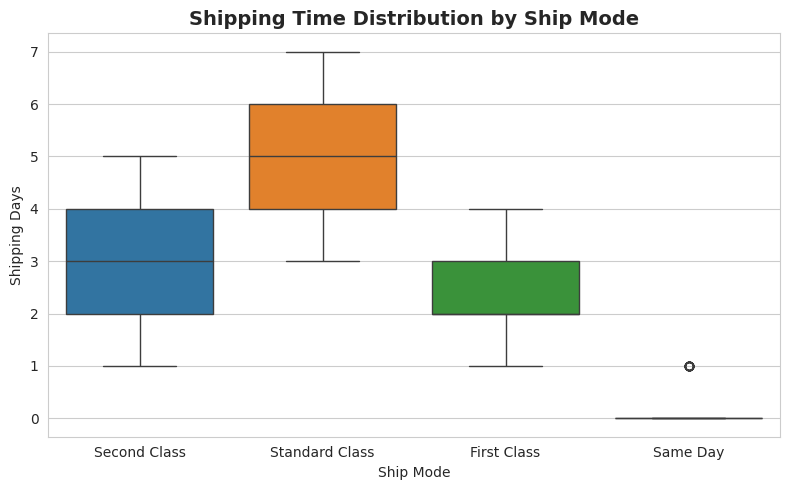

In [11]:
# Calculate shipping days
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Ship Mode', y='Shipping Days', hue='Ship Mode', legend=False)
plt.title('Shipping Time Distribution by Ship Mode', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shipping_days_by_mode.png', dpi=120)
plt.show()

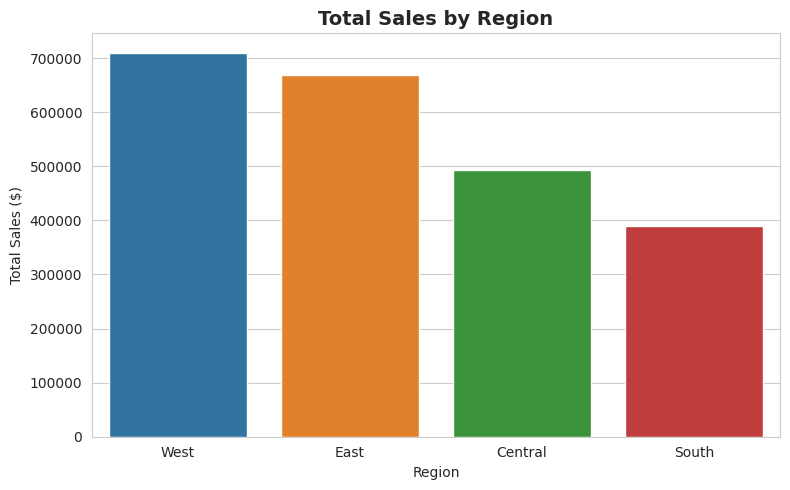

In [12]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=region_sales.index, y=region_sales.values, hue=region_sales.index, legend=False)
plt.title('Total Sales by Region', fontsize=14, fontweight='bold')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('sales_by_region.png', dpi=120)
plt.show()